<div style="background:linear-gradient(135deg,#0a1230 0%,#141d44 55%,#1b1448 100%);border-radius:18px;padding:36px 32px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#00d4ff;font-weight:700;text-transform:uppercase">Part II · Describing Data &nbsp;|&nbsp; Chapter 13</div>
  <div style="font-size:40px;font-weight:900;line-height:1.1;margin:10px 0 6px">Frequency Distributions <span style="color:#00d4ff">🐍 Notebook</span></div>
  <div style="font-size:16px;color:#b9c2e0;max-width:720px;line-height:1.6">Five demos on organizing data by how often it occurs: counting with frequency tables, binning continuous data into classes, the relative and cumulative columns, drawing histograms, polygons and ogives, and the weighted mean hiding inside a grouped table.</div>
  <div style="margin-top:18px;font-size:13px;color:#8892b0">Author: <b style="color:#e8eaf6">John Fisher</b> &nbsp;·&nbsp; Statistics, Data Science and AI: A Visual Handbook &nbsp;·&nbsp; 2026</div>
</div>

### 🎯 What you'll build in this notebook

| # | Demo | Idea it builds |
|---|------|----------------|
| 1 | Counting things | an ungrouped frequency table with relative frequency |
| 2 | Binning into classes | a grouped table with relative & cumulative columns |
| 3 | Three pictures | histogram, frequency polygon, and ogive from one dataset |
| 4 | The weighted mean | GPA-style average where weights matter |
| 5 | Grouped mean | a weighted mean of midpoints, and its approximation error |

---

## ⚙️ Setup, imports & the book's plotting style

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(13)

NAVY="#0a1230"; INK="#1a2138"; INK_SOFT="#4a5578"
CYAN="#0891b2"; PURPLE="#7c3aed"; AMBER="#d97706"; GREEN="#059669"; PINK="#db2777"; BLUE="#2563eb"; GRID="#e6e9f2"
plt.rcParams.update({
    "figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
    "axes.edgecolor":GRID,"axes.linewidth":1.2,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,
    "axes.spines.top":False,"axes.spines.right":False,"axes.titlesize":13,"axes.titleweight":"bold","axes.titlecolor":INK,
    "axes.labelcolor":INK_SOFT,"axes.labelsize":11.5,"xtick.color":INK_SOFT,"ytick.color":INK_SOFT,"legend.frameon":False,
})
print("✅ Environment ready.")

✅ Environment ready.


<div style="background:#e0f7fb;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0891b2;letter-spacing:1px">DEMO 1 · COUNTING THINGS</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🧮 The ungrouped frequency table</div>
<div style="color:#4a5578;margin-top:6px">For a handful of distinct values, a frequency table just pairs each value with its count. Add a relative-frequency column (count / total) and it must sum to 1.</div>
</div>

       frequency  relative  percent
grade                              
A              4     0.286     28.6
B              6     0.429     42.9
C              3     0.214     21.4
D              1     0.071      7.1

relative frequencies sum to 1.000  (should be 1.000)


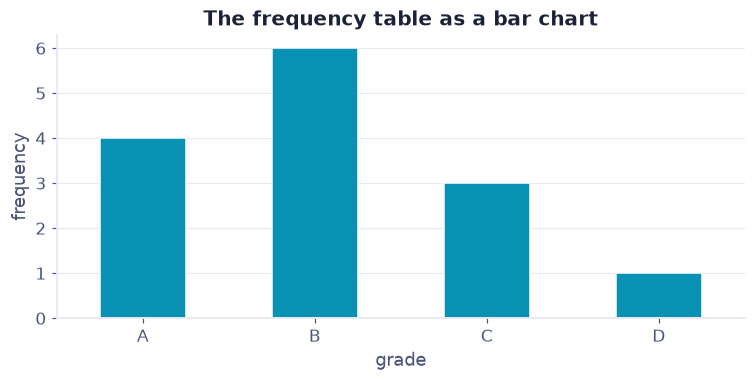

In [2]:
ratings = pd.Series(list("AABBBBCCCABBDA"), name="grade")

freq = ratings.value_counts().sort_index()
table = pd.DataFrame({"frequency": freq})
table["relative"] = (table["frequency"] / table["frequency"].sum()).round(3)
table["percent"]  = (table["relative"] * 100).round(1)
print(table)
print(f"\nrelative frequencies sum to {table['relative'].sum():.3f}  (should be 1.000)")

# --- added visual ---
import matplotlib.pyplot as plt, numpy as np
_CY,_PU,_AM,_GR,_PK,_INK,_GRY,_BL = "#0891b2","#7c3aed","#d97706","#059669","#db2777","#1a2138","#c7ccda","#2563eb"
fig, ax = plt.subplots(figsize=(7, 3.6))
freq.plot.bar(ax=ax, color=_CY, edgecolor="white")
ax.set_xlabel("grade"); ax.set_ylabel("frequency"); ax.set_title("The frequency table as a bar chart")
ax.tick_params(axis="x", rotation=0); ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

<div style="background:#f0e9fe;border-left:5px solid #7c3aed;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">DEMO 2 · BINNING INTO CLASSES</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">📦 A grouped frequency table</div>
<div style="color:#4a5578;margin-top:6px">Continuous data with many distinct values gets binned into equal-width classes. pandas pd.cut makes the classes; from there the relative, cumulative, and cumulative-relative columns are one line each.</div>
</div>

In [3]:
scores = pd.Series(rng.normal(68, 14, 80).clip(20, 100), name="score")

edges = [20, 35, 50, 65, 80, 95, 100]
classes = pd.cut(scores, bins=edges, right=False)         # equal-width-ish classes
f = classes.value_counts(sort=False)

tbl = pd.DataFrame({"frequency": f})
tbl["relative"]     = (tbl["frequency"] / tbl["frequency"].sum()).round(3)
tbl["cumulative"]   = tbl["frequency"].cumsum()
tbl["cum_relative"] = (tbl["cumulative"] / tbl["frequency"].sum()).round(3)
print(tbl)
print(f"\nlast cumulative = {tbl['cumulative'].iloc[-1]} = n,  last cum_relative = {tbl['cum_relative'].iloc[-1]:.3f} = 1.0")

           frequency  relative  cumulative  cum_relative
score                                                   
[20, 35)           2     0.025           2         0.025
[35, 50)           3     0.038           5         0.062
[50, 65)          27     0.338          32         0.400
[65, 80)          29     0.362          61         0.762
[80, 95)          18     0.225          79         0.988
[95, 100)          1     0.012          80         1.000

last cumulative = 80 = n,  last cum_relative = 1.000 = 1.0


<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#d97706;letter-spacing:1px">DEMO 3 · THREE PICTURES</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">📊 Histogram, polygon, ogive</div>
<div style="color:#4a5578;margin-top:6px">The same frequency counts drive three classic graphs. The histogram and polygon use class MIDPOINTS; the ogive plots cumulative frequency at class BOUNDARIES. That boundary-vs-midpoint distinction is the detail people miss.</div>
</div>

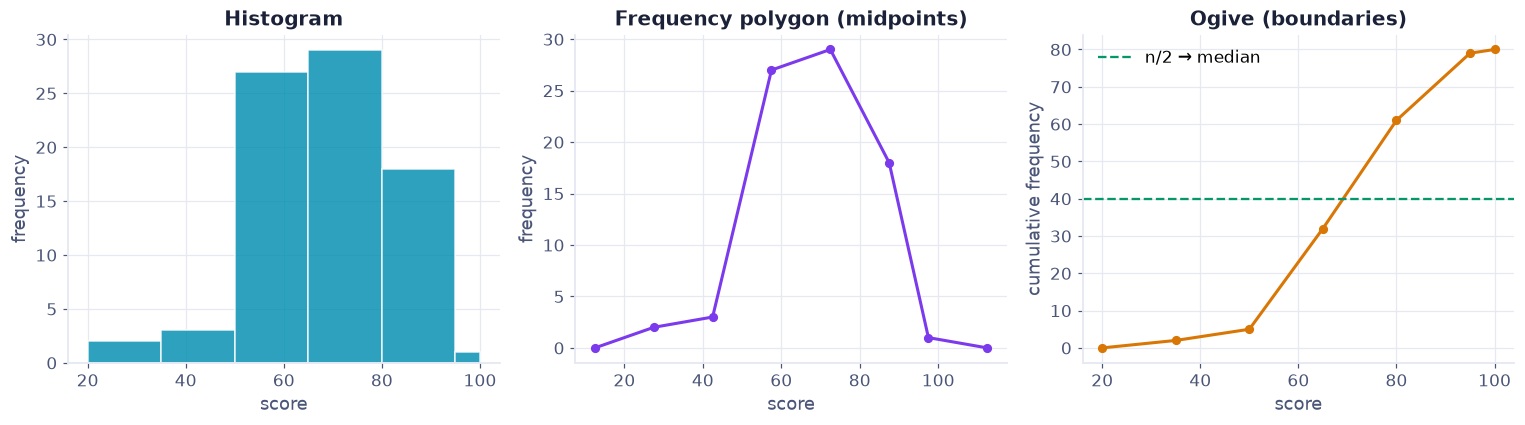

Histogram bars touch (continuous). Ogive rises to n. Read the median where the ogive crosses n/2.


In [4]:
counts, bin_edges = np.histogram(scores, bins=edges)
mids = (bin_edges[:-1] + bin_edges[1:]) / 2
cum  = np.cumsum(counts)

fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(14, 4))

a1.hist(scores, bins=edges, color=CYAN, alpha=0.85, edgecolor="white")
a1.set_title("Histogram"); a1.set_xlabel("score"); a1.set_ylabel("frequency")

# frequency polygon: midpoints, anchored to zero at both ends
px = np.concatenate([[mids[0]-15], mids, [mids[-1]+15]])
py = np.concatenate([[0], counts, [0]])
a2.plot(px, py, "-o", color=PURPLE, lw=2, markersize=5)
a2.set_title("Frequency polygon (midpoints)"); a2.set_xlabel("score"); a2.set_ylabel("frequency")

# ogive: cumulative frequency at upper boundaries, starting at (first boundary, 0)
ox = np.concatenate([[bin_edges[0]], bin_edges[1:]])
oy = np.concatenate([[0], cum])
a3.plot(ox, oy, "-o", color=AMBER, lw=2, markersize=5)
a3.axhline(len(scores)/2, color=GREEN, ls="--", lw=1.5, label="n/2 → median")
a3.set_title("Ogive (boundaries)"); a3.set_xlabel("score"); a3.set_ylabel("cumulative frequency"); a3.legend()
plt.tight_layout(); plt.show()
print("Histogram bars touch (continuous). Ogive rises to n. Read the median where the ogive crosses n/2.")

<div style="background:#e3f6ee;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#059669;letter-spacing:1px">DEMO 4 · THE WEIGHTED MEAN</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🏫 When some values count more</div>
<div style="color:#4a5578;margin-top:6px">A weighted mean is sum(w*x)/sum(w). GPA is the everyday example: grades weighted by credit hours. The plain average ignores that a 4-credit course should pull harder than a 1-credit one.</div>
</div>

In [5]:
grades  = np.array([4.0, 3.0, 4.0, 2.0])   # A, B, A, C as grade points
credits = np.array([4,   4,   3,   1  ])   # weights

weighted = np.average(grades, weights=credits)
plain    = grades.mean()
print(f"weighted GPA (by credits) = {weighted:.2f}")
print(f"plain average of grades   = {plain:.2f}")
print("\nThe heavier (4-credit) courses pull the weighted GPA toward their grades.")

weighted GPA (by credits) = 3.50
plain average of grades   = 3.25

The heavier (4-credit) courses pull the weighted GPA toward their grades.


<div style="background:#e6effe;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#2563eb;letter-spacing:1px">DEMO 5 · THE GROUPED MEAN</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">📐 A weighted mean of midpoints</div>
<div style="color:#4a5578;margin-top:6px">Once data is grouped you no longer have the exact values, so the mean is estimated by treating every value in a class as its midpoint: mean ≈ sum(f*m)/sum(f). That is just a weighted mean, and it differs slightly from the true mean.</div>
</div>

true mean (from raw data)      = 69.92
grouped mean (from the table)  = 68.88
approximation error            = 1.05

Grouping trades exact values for a tidy summary: the grouped mean is close, not exact.


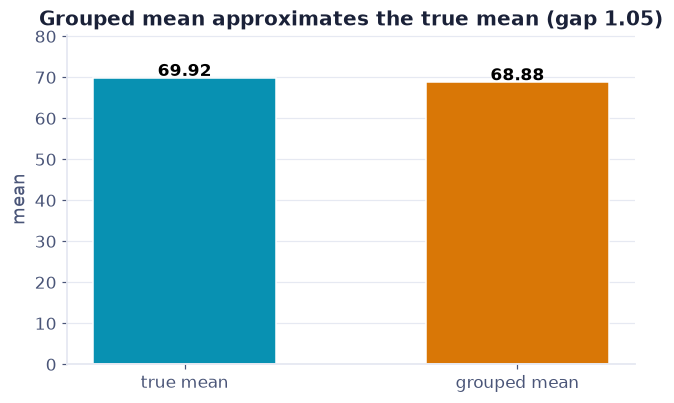

In [6]:
true_mean = scores.mean()

# estimate from the grouped table alone, using midpoints weighted by frequency
grouped_mean = np.average(mids, weights=counts)

print(f"true mean (from raw data)      = {true_mean:.2f}")
print(f"grouped mean (from the table)  = {grouped_mean:.2f}")
print(f"approximation error            = {abs(true_mean - grouped_mean):.2f}")
print("\nGrouping trades exact values for a tidy summary: the grouped mean is close, not exact.")

# --- added visual ---
import matplotlib.pyplot as plt, numpy as np
_CY,_PU,_AM,_GR,_PK,_INK,_GRY,_BL = "#0891b2","#7c3aed","#d97706","#059669","#db2777","#1a2138","#c7ccda","#2563eb"
fig, ax = plt.subplots(figsize=(6, 3.8))
ax.bar(["true mean","grouped mean"], [true_mean, grouped_mean], color=[_CY,_AM], edgecolor="white", width=0.55)
ax.set_ylabel("mean"); ax.set_ylim(0, max(true_mean, grouped_mean)*1.15)
for i, v in enumerate([true_mean, grouped_mean]): ax.text(i, v+0.4, f"{v:.2f}", ha="center", fontweight="bold")
ax.set_title(f"Grouped mean approximates the true mean (gap {abs(true_mean-grouped_mean):.2f})")
ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:24px 28px;font-family:Inter,sans-serif;box-shadow:0 8px 30px rgba(20,30,80,0.05)">
<div style="font-size:20px;font-weight:800;color:#1a2138">🎓 Recap</div>
<ul style="color:#4a5578;line-height:1.9;margin-top:10px">
<li>A <b>frequency table</b> pairs values (or classes) with counts; <b>relative</b> frequency = count / total and sums to 1.</li>
<li><b>Grouped</b> tables bin continuous data into classes, then add <b>cumulative</b> and <b>cumulative-relative</b> columns.</li>
<li>Histogram and polygon use <b>midpoints</b>; the <b>ogive</b> plots cumulative frequency at <b>boundaries</b> and crosses n/2 at the median.</li>
<li>A <b>weighted mean</b> = sum(w*x)/sum(w); GPA is the classic case.</li>
<li>The <b>grouped mean</b> is a weighted mean of class midpoints, close to but not equal to the true mean.</li>
</ul>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:18px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>